# General
Template for labjournaal. See https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html for options to use markdown.

**Name:**  Lukas Calixtro & Oskar van Velze  
**Title of the experiment:**  Een benadering van de invloed van valsnelheid op het verschil tussen ideale en non-ideale val
**Starting date:**  09/01/26  
**Expected enddate:**  23/01/26   
**Goal of the experiment:**  Bepalen welke invloed verliezen m.b.t. de valsnelheid hebben op de val van waterdruppels
**Research question:**  Wat is het effect van de valsnelheid op de afweiking tussen de ideale en non-ideale val
**Expectations or Hypothesis:**  Hoe groter de snelheid hoe groter het verschil. Wij verwachten ook dat de weerstand zal toenemen met snelheid.
**Desired accuracy:**  >50%




In [1]:
#import necessary libraries
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.optimize import curve_fit 

# Preparation
 


**Assignments:**  



Het doel van dit onderzoek om de verliezen, van voornamelijk de wrijving, te benaderen door te meten aan een vallende waterdruppel. Door van verschillende valhoogtes te meten bereiken de waterdruppels verschillende snelheden, vervolgens wordt deze data vergeleken met de theoretische waardes.

**Method:**  
**Theory:**  
**Independent variable:**  
1. Valhoogte  

**Dependent variable:**  
1. Valtijd  

**Controlled variablen:**  
1. Vorm en grootte van druppel
2. Valversnelling  

In dit experiment wordt geprobeerd om de relatie tussen de valsnelheid en het verschil van ideale en non-ideale val aan te tonen. Dit wordt gedaan door gebruik
te maken van de standaard opstelling die getoond wordt in beide figuur 14.8
van de handleiding en hier rechts. Waarbij de bovenste detector wordt
geplaatst net onder de pipet, met markeringen v0=s0=t0=0 en de detector
onder, net boven de grond. De hoogte wordt gevariëerd om de druppels op verschillende snelheden te krijgen. Metingen op elke hoogte worden 10 keer herhaald, waar vervolgens het gemiddelde van wordt gepakt. De gemiddelde meting wordt vervolgens gebruikt om $\beta$ te fitten. Daarmee wordt de bereikte snelheid berekend, welke vervolgens wordt vergeleken met het theoretische model voor een ideale val.

**Measurement instruments \& Settings:**  

Standaard pipet, twee optische sensoren met fotoreceptoren, timer, camera op 70x1.5mm - ISO 1000 - 1/320 - f/8.0, vari-snelheid luchtblazer.

**Procedure:**  

Dezelfde persoon doet elke meting om verschil in druppels te minimaliseren. Het meetinstrument wordt na elke meting uit en aan gezet om de timer te resetten.

**Setup(drawing or picture):**  

Standaard meetopstelling voor val met wrijving.


# Execution

In [2]:
rho_water = 998.2       #Dichtheid van water (kg.m^-3)
rho_lucht = 1.225       #Dichtheid van lucht (kg.m^-3)
g = 9.812               #Valversnelling (m/s^-2)


In [3]:
#Raw Data
Data = np.loadtxt('Raw_ValWrijving.csv',delimiter=';', skiprows=1)      #Data importeren

**Observations:**  
- Een grotere valhoogte zorgde voor een een steeds grotere valtijd, wat volgens verwachtingen is.
- Tijdens het meten, miste de druppel soms de tweede sensor, deze gevallen werden verder genegeerd.
- Wanneer een druppel op een verschillende manier uit het pipet druppelt, ontstaat een klein verschil in de valtijd. Hierom werd er voor gezorgd dat ieder druppel op dezelfde manier eruit druppelde.

**Notes:**  
- Onzekerheid groot meetlint: ?
- Onzekerheid sensoren: 0.005s
- Onzekerheid (?): ?

# Processing
**Description of processing of raw data into scientific evidence:**


<function matplotlib.pyplot.show(close=None, block=None)>

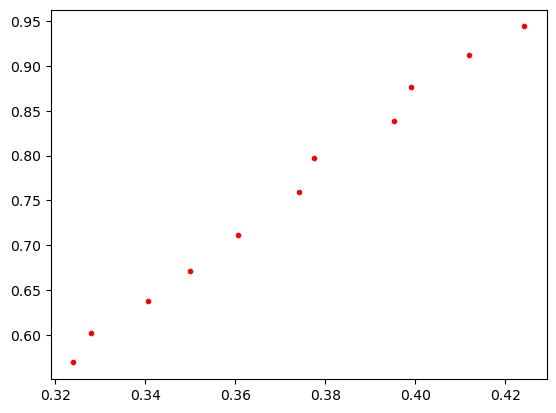

In [4]:
#Data processing and analysis:

Hoogte_Data = Data[:,0]     #Valhoogte (m)
u_Hoogte = 0.0005           #Onzekerheid valhoogte (m)

#Alle 10 valtijd metingen per hoogte (s)
Val_Data1 = Data[0,1:]
Val_Data2 = Data[1,1:]
Val_Data3 = Data[2,1:]
Val_Data4 = Data[3,1:]
Val_Data5 = Data[4,1:]
Val_Data6 = Data[5,1:]
Val_Data7 = Data[6,1:]
Val_Data8 = Data[7,1:]
Val_Data9 = Data[8,1:]
Val_Data10 = Data[9,1:]
Val_Data11 = Data[10,1:]

#Gemiddelde valtijd per hoogte (s)
Val_tijd1 = np.mean(Val_Data1)
Val_tijd2 = np.mean(Val_Data2)
Val_tijd3 = np.mean(Val_Data3)
Val_tijd4 = np.mean(Val_Data4)
Val_tijd5 = np.mean(Val_Data5)
Val_tijd6 = np.mean(Val_Data6)
Val_tijd7 = np.mean(Val_Data7)
Val_tijd8 = np.mean(Val_Data8)
Val_tijd9 = np.mean(Val_Data9)
Val_tijd10 = np.mean(Val_Data10)
Val_tijd11 = np.mean(Val_Data11)
 

Val_tijden = np.array([Val_tijd1, Val_tijd2, Val_tijd3, Val_tijd4, Val_tijd5, Val_tijd6, Val_tijd7, Val_tijd8, Val_tijd9, Val_tijd10, Val_tijd11])
u_tijden = 0.0005   #Onzekerheid valtijd (s)

#Test plot
plt.figure()
plt.plot(Val_tijden, Hoogte_Data, 'r.')
plt.show



Voor nauwkeurige gegevens van de waterdruppels zijn 3 fotos gebruikt om de diameter te bepalen. Daarmee is de gemiddelde genomen, waarbij een standaarddeviatie en onzekerheid ook bijhoort.

$$
    \bar{D} = \frac{D_1 + D_2 + D_3}{3} 
    \rightarrow
    SD = \sqrt{\frac{1}{n-1} \sum (D_i - \bar{D})^2} 
    \rightarrow u_{\bar{D}} = \frac{SD}{\sqrt{3}}
    $$

De waardes voor de diameter zijn nodig om de straal van de druppels te berekenen en daarvan ook de onzekerheid.

$$
    \bar{r} = \frac{\bar{D}}{2}
    \rightarrow
    u_{r} = \frac{u_{D}}{2}

    $$

De waardes voor de straal zijn nodig om de frontale oppervlakte en de volume te berekenen, wat hun eigen onzekerheden ook hebben.

$$
    \bar{V} = \frac{4}{3}\pi \bar{r}^3 
    \rightarrow 
    u_{V} = \left|\frac{dV}{dr}\right|u_{r}
    \rightarrow
    u_{V} = 4\pi r^2 u_{r}
    $$

$$
    \bar{A} = \pi \bar{r}^2 
    \rightarrow 
    u_{A} = \left|\frac{dA}{dr}\right|u_{r}
    \rightarrow
    u_{A} = 2\pi r u_{r}
    $$

De waardes voor volume zijn nodig om de massa van de druppels te berekenen en ook hiervan de onzekerheid.

$$
    \bar{m} = \rho_{water} \bar{V}
    \rightarrow
    u_{m} = \rho_{water} u_{V}

In [5]:
#Data processing and analysis:
L_naald = 0.0105 #Daadwerkelijke lengte van naald (m)

#Diameters zijn berekend met behulp van Fiji-software en schaal van L_naald
#Aangenomen dat alle druppels perfect bolvormig zijn, ook al zijn ze dat in de fotos niet helemaal
#Uit de fotos afgeleide diameters (m)
D_druppel1 = 0.003875 
D_druppel2 = 0.003993 
D_druppel3 = 0.003888

D_druppel_gem = (D_druppel1 + D_druppel2 + D_druppel3)/3    #Gemiddelde diameter (m)
s_D_druppel = np.sqrt(1/2 * ((D_druppel1-D_druppel_gem)**2 + (D_druppel2-D_druppel_gem)**2 + (D_druppel3-D_druppel_gem)**2))        #Standaarddeviatie van diameters
u_D_druppel = s_D_druppel/np.sqrt(3)        #Onzekerheid diameter op basis van standaarddeviatie(m)

#Straal van druppels (m)
R_druppel1 = D_druppel1/2
R_druppel2 = D_druppel2/2
R_druppel3 = D_druppel3/2

R_druppel_gem = D_druppel_gem/2
u_R_druppel = u_D_druppel/2     #Onzekerheid straal

#Frontale oppervlakte van druppels (m^2)
A_druppel_gem = np.pi*R_druppel_gem**2
u_A_druppel = 2*np.pi*R_druppel_gem*u_R_druppel     #Onzekerheid frontale oppervlakte

#Volume van druppels (m^3)
#Aangenomen dat druppels perfect bolvormig zijn
V_druppel_gem = (4/3)*np.pi*R_druppel_gem**3
u_V_druppel = 4*np.pi*R_druppel_gem**2*u_D_druppel      #Onzekerheid volume

#Massa van druppels (kg)
m_druppel_gem = rho_water*V_druppel_gem
u_m_druppel = rho_water*u_V_druppel       #Onzekerheid massa

**Describing the pattern in the processed data:**  


Door de beweginsvergelijking van een vallende voorwerp twee keer te integereren krijgen wij de equation of motion:
$$
    \frac{1}{2}gt^2 - s(t) = \frac{\beta g^2}{12m}t^4 
    \rightarrow 
    s(t) = v_{0}t + \frac{1}{2}gt^2 - \frac{c_{D} A_{\perp} \rho_{l}}{24m}g^2t^4 

    $$

Hiermee is s(t) het afgelegde afstand, deze is gelijk aan de valhoogte. Het experiment is opgesteld zodat op s_0 = 0.

Door de meetdata te fitten aan deze formule, krijgen we waardes voor $v_0$ en $C_D$. Er hoort voor zowel de $v_0$ als de $C_D$ een onzekerheid afkomistig van de fit. Maar de $C_D$ heeft ook een sysytematische onzekerheid van de waardes van A en m. 
$$
    u_{C_{D},system} = C_D \sqrt{(\frac{u_A}{A})^2 + (\frac{u_m}{m})^2}
    $$

Deze twee onzekerheden moeten worden samengevoegd om de totale onzekerheid van $C_D$ te berekenen.
$$
    u_{C_{D}} = \sqrt{(u_{C_{D},fit})^2 + (u_{C_{D},system})^2}

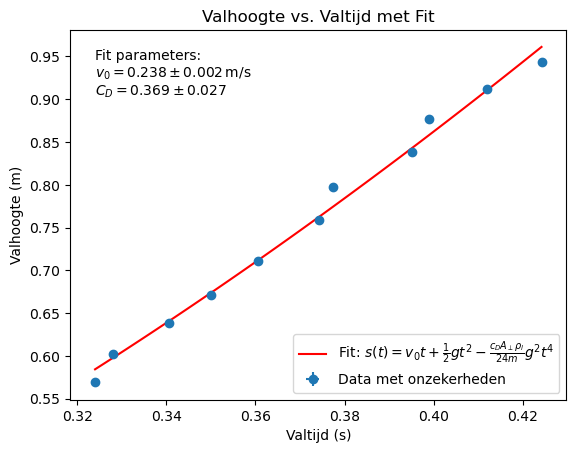

v_0 = 0.238 m/s +/- 0.002 m/s
C_D = 0.369 m/s +/- 0.016 kg/m


In [30]:
#Functie defineren voor bewegingsvergelijking
def func_s(t,v_0, C_D):
    return v_0*t + 1/2*g*t**2 - (C_D * A_druppel_gem * rho_lucht)/(24 * m_druppel_gem) * g**2 *t**4

#Fitten van functie
popt, pcov = curve_fit(func_s, Val_tijden, Hoogte_Data, p0 =[0.0, 0.5], sigma=np.full_like(Hoogte_Data, u_Hoogte), absolute_sigma=True)
v_0_fit, C_D_fit = popt

#Onzekerheden van fit
u_v_0_fit, u_C_D_fit = np.sqrt(np.diag(pcov))

#Onzekerheid in C_D
u_C_D_sys = C_D_fit * np.sqrt((u_A_druppel/A_druppel_gem)**2 + (u_m_druppel/m_druppel_gem)**2) #Systematische onzekerheid in C_D door onzekerheden in A en m
u_CD = np.sqrt(u_C_D_fit**2 + u_C_D_sys**2) #Totale onzekerheid in C_D

#Plotten van data met fit
Tijden_fit = np.linspace(min(Val_tijden), max(Val_tijden), 100)
Hoogte_fit = func_s(Tijden_fit,v_0_fit, C_D_fit)

textstr = ('Fit parameters:' '\n'
           rf'$v_0 = {v_0_fit:.3f} \pm {u_v_0_fit:.3f}\,\mathrm{{m/s}}$' '\n'
           rf'$C_D = {C_D_fit:.3f} \pm {u_CD:.3f}$')

plt.errorbar(Val_tijden, Hoogte_Data, xerr=u_tijden, yerr=u_Hoogte, fmt='o', label='Data met onzekerheden')
plt.plot(Tijden_fit, Hoogte_fit, 'r-', label=r'Fit: $s(t)=v_0 t + \frac{1}{2} g t^2 - \frac{c_D A_{\perp} \rho_l}{24m} g^2 t^4$')
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top')
plt.xlabel('Valtijd (s)')
plt.ylabel('Valhoogte (m)')
plt.title('Valhoogte vs. Valtijd met Fit')
plt.legend()
plt.savefig("fit_zoom_in.jpg", dpi=450, bbox_inches='tight')
plt.show()


print('v_0 = {:.3f} m/s +/- {:.3f} m/s' .format(v_0_fit, u_v_0_fit))
print('C_D = {:.3f} m/s +/- {:.3f} kg/m' .format(C_D_fit, u_C_D_fit))

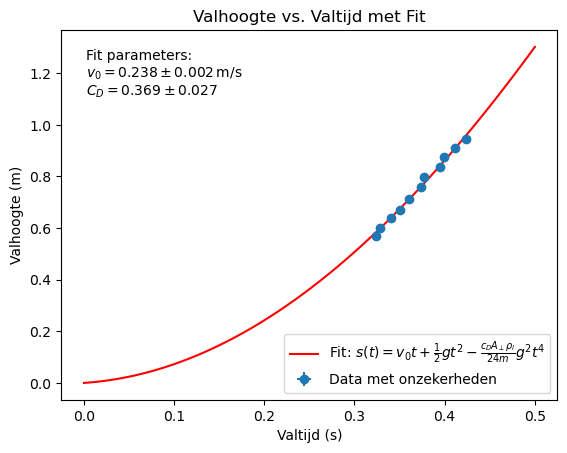

In [31]:
textstr = ('Fit parameters:' '\n'
           rf'$v_0 = {v_0_fit:.3f} \pm {u_v_0_fit:.3f}\,\mathrm{{m/s}}$' '\n'
           rf'$C_D = {C_D_fit:.3f} \pm {u_CD:.3f}$')

plt.errorbar(Val_tijden, Hoogte_Data, xerr=u_tijden, yerr=u_Hoogte, fmt='o', label='Data met onzekerheden')
plt.plot(np.linspace(0,0.5,100), func_s(np.linspace(0,0.5,100),v_0_fit,C_D_fit), 'r-', label=r'Fit: $s(t)=v_0 t + \frac{1}{2} g t^2 - \frac{c_D A_{\perp} \rho_l}{24m} g^2 t^4$')
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top')
plt.xlabel('Valtijd (s)')
plt.ylabel('Valhoogte (m)')
plt.title('Valhoogte vs. Valtijd met Fit')
plt.legend()
plt.savefig("fit_zoom_out.jpg", dpi=450, bbox_inches='tight')
plt.show()


**Notes:**  

# Discussion



# Conclusion

# Additional notes, remarks, explanations, thoughts etc